# Machine learning model

## Setup

### Imports, global constants and functions

In [3]:
import pandas as pd
import glob #For combining individual files into one dataframe
from pathlib import Path
import matplotlib.pyplot as plt

In [4]:
def load_parquet(path_pattern: str, engine='fastparquet') -> pd.DataFrame:
    """
    Loads parquet file(s).
    Supports glob patterns like "*.parquet.gzip".
    
    Args:
        path_pattern: File path or glob pattern.
        engine: Parquet engine.

    Returns:
        Single DataFrame, concatenated if multiple files.
    """

    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files found matching: {path_pattern}")
    
    dfs = [pd.read_parquet(f, engine=engine) for f in files]
    df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
    print(f"Loaded {len(df):,} rows from {len(dfs)} files matching \"{path_pattern}\"")
    
    return df

### Load AIS data and voyage META data
We're only interested in arrivals to Valencia, as it's there we aim to optimize berth allocation and scheduling, thus we can forego departures.

In [5]:
arrivals_ais_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip")
arrivals_ais_meta_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip")

Loaded 3,311,442 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip"
Loaded 43,352 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip"


## Exploratory data analysis

### Inspect AIS data

In [81]:
arrivals_ais_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3311356 entries, 0 to 3311441
Data columns (total 50 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   voyage_id              object        
 1   voyage_status          object        
 2   mmsi                   int64         
 3   pos_timestamp          datetime64[ns]
 4   navigation_status      object        
 5   position_accuracy      bool          
 6   longitude              float64       
 7   latitude               float64       
 8   course_over_ground     float64       
 9   true_heading           int64         
 10  timestamp_seconds      int64         
 11  raim                   bool          
 12  rate_of_turn           float64       
 13  speed_over_ground      float64       
 14  pos_source             object        
 15  call_sign              object        
 16  name                   object        
 17  ship_type              int64         
 18  ref_point_a            int6

In [6]:
arrivals_ais_data.shape

(3311442, 50)

In [7]:
arrivals_ais_data.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month'],
      dtype='object')

In [8]:
arrivals_ais_data.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,capacity_liquid_gas,capacity_passenger,capacity_liquid_oil,commercial_size_class,vessel_type_details,draught_max,draught_min,capacity_nt,vid_prefix,month
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01


#### Remove duplicates

In [9]:
print(f"Total rows: {len(arrivals_ais_data)}")
print(f"Duplicate rows: {arrivals_ais_data.duplicated().sum()}")

Total rows: 3311442
Duplicate rows: 86


In [10]:
arrivals_ais_data.drop_duplicates(keep="first", inplace=True)

#### Check for missing values

In [11]:
arrivals_ais_data.isna().sum()

voyage_id                      0
voyage_status                  0
mmsi                           0
pos_timestamp                  0
navigation_status              0
position_accuracy              0
longitude                      0
latitude                       0
course_over_ground             0
true_heading                   0
timestamp_seconds              0
raim                           0
rate_of_turn                   0
speed_over_ground              0
pos_source                     0
call_sign                      0
name                           0
ship_type                      0
ref_point_a                    0
ref_point_b                    0
ref_point_c                    0
ref_point_d                    0
position_device                0
eta                      1640039
draught                        0
destination                    0
meta_timestamp                 0
imo                            0
meta_source                    0
flag                           0
build_year

In [12]:
arrivals_ais_data["eta"].isna().mean() * 100

np.float64(49.527716138041335)

49.53% of AIS data doesn't have a valid ETA

### Inspect voyage META data

In [13]:
arrivals_ais_meta_data.shape

(43352, 17)

In [14]:
arrivals_ais_meta_data.columns

Index(['voyage_id', 'mmsi', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude',
       'prev_voyage_id', 'next_voyage_id', 'departed_port_call_id',
       'arrived_port_call_id', 'duration', 'arrival_country', 'arrival_date'],
      dtype='object')

In [15]:
arrivals_ais_meta_data.head()

,voyage_id,mmsi,departure_time,departure_locode,departure_latitude,departure_longitude,arrival_time,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,f4a7d707-95c8-4e3f-93f4-c6000e57853a,224208000,2024-01-15 22:57:24,ESVLC,39.441430,-0.317925,2024-01-15 23:58:36,ESVLC,39.442105,-0.317382,f49ebf4b-71a0-4c81-8317-59d5930c79ed,864c813c-e3d1-4627-9088-750d4bcb9f96,,,3672.0,ES,2024-01-16
1,597c19e1-449b-49a3-9044-62788862926a,225952430,2024-01-15 22:54:55,ESVLC,39.421110,-0.329000,2024-01-16 00:00:00,ESVLC,39.424800,-0.327170,b228aff6-44bb-479c-8cef-ea39fd47b4f0,f01811e2-e6ce-49e6-8877-60d7b326d46e,,,3905.0,ES,2024-01-16
2,ec23c291-f150-4314-a4b7-5834e47c7f7a,255915587,2024-01-15 22:22:37,ESVLC,39.394322,-0.275112,2024-01-16 00:33:06,ESVLC,39.434488,-0.327693,776e4362-e3f9-47ea-97d4-df89891f1204,03f0aad7-0ec9-4f83-a8d4-335b75906a29,,,7829.0,ES,2024-01-16
3,98074eeb-fe2a-4478-8e51-8c9ea2aed4f6,205345130,2024-01-15 22:53:39,ESVLC,39.430230,-0.332620,2024-01-16 00:29:40,ESVLC,39.430240,-0.332640,2737f7cd-015c-45bc-9bd4-d0f2134b917c,e20b07a6-59b9-47f0-92af-c91892a34149,,,5761.0,ES,2024-01-16
4,4c617e21-5ff2-423e-9c81-d4e3b61986dd,255806500,2024-01-15 11:17:21,ESBCN,41.310288,2.150347,2024-01-16 00:39:26,ESVLC,39.439080,-0.325422,115375ca-6147-4c60-910f-13ef7da40f06,2d6446e8-b61b-4da4-aefe-9d949aaac8ec,,,48125.0,ES,2024-01-16


#### Remove duplicates

In [16]:
print(f"Total rows: {len(arrivals_ais_meta_data)}")
print(f"Duplicate rows: {arrivals_ais_meta_data.duplicated().sum()}")

Total rows: 43352
Duplicate rows: 0


#### Check for missing values

In [17]:
arrivals_ais_meta_data.isna().sum()

voyage_id                0
mmsi                     0
departure_time           0
departure_locode         0
departure_latitude       0
departure_longitude      0
arrival_time             0
arrival_locode           0
arrival_latitude         0
arrival_longitude        0
prev_voyage_id           0
next_voyage_id           0
departed_port_call_id    0
arrived_port_call_id     0
duration                 0
arrival_country          0
arrival_date             0
dtype: int64

### Merging AIS data with voyage META data
The AIS data is the dynamic, continuously transmitted AIS data samples from vessels, whereas the META data represents the static information of the voyage.
This means the META data includes e.g. the duration of the voyage, i.e. our truth values for supervised ML.
Thus we merge them into a single DataFrame.

In [18]:
ais_meta_merged = arrivals_ais_data.merge(
    arrivals_ais_meta_data,
    on="voyage_id",
    how="left",
    suffixes=("_ais", "_meta"), # column name suffix if both DataFrames contain the same column
)

In [19]:
ais_meta_merged.shape

(3311356, 66)

In [20]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'mmsi_meta', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_locode', 'arrival_latitude',
  

In [21]:
ais_meta_merged.head()

,voyage_id,voyage_status,mmsi_ais,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01


### Check if mmsi_ais and mmsi_meta are equal

In [22]:
same_mmsi_mask = ais_meta_merged["mmsi_ais"] == ais_meta_merged["mmsi_meta"]
pct_same = same_mmsi_mask.mean() * 100
print(f"mmsi_ais and mmsi_meta match in {pct_same:.2f}% of merged rows")

mmsi_ais and mmsi_meta match in 100.00% of merged rows


#### Good, drop mmsi_meta column and rename mmsi_ais to mmsi

In [23]:
ais_meta_merged = ais_meta_merged.drop("mmsi_meta", axis="columns")
ais_meta_merged.rename(columns={"mmsi_ais": "mmsi"}, inplace=True)
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Determining the actual time of arrival

#### To determine the actual time of arrival (ATA) we will use a simplistic definition of "if vessel is in bounding box, it's ready to berthe".

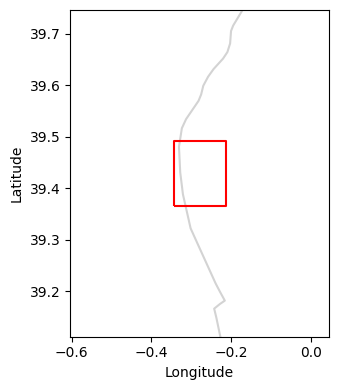

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

coastline = gpd.read_file("./data/ne_10m_coastline/ne_10m_coastline.shp")
max_lat = 39.492119
min_lat = 39.3653539
min_lon = -0.343666
max_lon = -0.213547

bbox = box(min_lon, min_lat, max_lon, max_lat)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs="EPSG:4326") # Coordinat Reference System, WGS84 lat/long in degrees

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
coastline.plot(ax=ax, color="lightgrey")
bbox_gdf.boundary.plot(ax=ax, edgecolor="red")

# Add padding around bbox (200%)
pad_lon = (max_lon - min_lon) * 2
pad_lat = (max_lat - min_lat) * 2
ax.set_xlim(min_lon - pad_lon, max_lon + pad_lon)
ax.set_ylim(min_lat - pad_lat, max_lat + pad_lat)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


## Pre-processing

### Defining the population

#### Filter out non-commercial vessels

In [25]:
ais_meta_merged["vessel_type_details"].unique()

array(['', 'Bulk Carrier', 'General Dry Cargo', 'Chemical Tanker',
       'Container Ship', 'Offshore', 'Tanker', 'Roll-on Roll-off',
       'Vehicle/Passenger', 'Pure Car Carrier', 'Miscellaneous',
       'Passenger Ship', 'LPG Carrier'], dtype=object)

In [26]:
ais_meta_merged["vessel_type_details"].value_counts(normalize=True).mul(100).round(2)

vessel_type_details
                     64.83
Container Ship       23.16
Roll-on Roll-off      2.51
Chemical Tanker       2.12
Tanker                1.91
General Dry Cargo     1.32
Pure Car Carrier      1.32
Bulk Carrier          1.26
Offshore              1.22
Vehicle/Passenger     0.24
Passenger Ship        0.06
Miscellaneous         0.05
LPG Carrier           0.01
Name: proportion, dtype: float64

In [27]:
VALID_VESSEL_TYPES = ["Bulk Carrier", "General Dry Cargo", "Chemical Tanker", "Container Ship", "Tanker", "LPG Carrier", "Pure Car Carrier", "Roll-on Roll-off"]

mask = ais_meta_merged["vessel_type_details"].isin(VALID_VESSEL_TYPES)
cargo_ais_meta_merged = ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
10,01f80139-2bd0-4ff0-8cdd-33c0064ba220,PENDING_DEPARTURE,577005000,2024-01-29 21:02:50,MOORED,False,-0.321315,39.445050,178.199997,111,...,ESVLC,39.445048,-0.321325,10b4dad4-687a-48c3-ad7d-0d79adea92e7,a6910090-2954-47dc-89ad-22f0139013d7,,,3611.0,ES,2024-01-31


#### Filter out voyages with invalid voyage status

In [28]:
cargo_ais_meta_merged["voyage_status"].unique()

array(['STOPPED', 'PENDING_DEPARTURE', 'UNDER_WAY', 'COMPLETED'],
      dtype=object)

In [29]:
cargo_ais_meta_merged["voyage_status"].value_counts(normalize=True).mul(100).round(2)

voyage_status
UNDER_WAY            51.19
PENDING_DEPARTURE    32.44
STOPPED              15.63
COMPLETED             0.74
Name: proportion, dtype: float64

In [30]:
VALID_VOYAGE_STATUSES = ["UNDER_WAY", "STOPPED"]

mask = cargo_ais_meta_merged["voyage_status"].isin(VALID_VOYAGE_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,ESVLC,39.444928,-0.32074,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03


#### Filter out voyages with missing MMSI

In [31]:
voyages_with_valid_mmsi_pct = cargo_ais_meta_merged["mmsi"].notna().mean() * 100
print(f"Voyages with valid MMSI: {voyages_with_valid_mmsi_pct:.2f}%")

Voyages with valid MMSI: 100.00%


#### Filter out AIS data past actual time of arrival to isolate the voyage from the "waiting to be berthed" stage

In [32]:
max_lat = 39.492119
min_lat = 39.3653539
min_lon = -0.343666
max_lon = -0.213547

in_bbox = (
    (cargo_ais_meta_merged["latitude"].between(min_lat, max_lat)) &
    (cargo_ais_meta_merged["longitude"].between(min_lon, max_lon))
)

cargo_ais_meta_merged["in_bbox"] = in_bbox

In [33]:
cargo_ais_meta_merged["in_bbox"].sample(10)

2401031     True
61584      False
2986064    False
3275246    False
359422     False
896286      True
3193794     True
1973777    False
837474     False
2496412     True
Name: in_bbox, dtype: bool

In [34]:
cargo_ais_meta_merged.iloc[359223]

voyage_id               d098c2b9-648a-46bb-9568-e3e566b360a5
voyage_status                                      UNDER_WAY
mmsi                                               636014971
pos_timestamp                            2024-06-28 18:28:23
navigation_status                    UNDER_WAY_USING_ENGINES
                                        ...                 
arrived_port_call_id                                        
duration                                            166888.0
arrival_country                                           ES
arrival_date                                      2024-06-30
in_bbox                                                False
Name: 1640896, Length: 66, dtype: object

Above we see that voyage_status: STOPPED, navigation_status: AT_ANCHOR, in_bbox: True, yet tta_hours: 42.156111.
<br>This means the arrival_time is when it HAS berthed and not when it arrived outside the harbor and is waiting for a berthing spot.
<br>Trim all remaining data points after in_bbox becomes true.

In [35]:
# Sort by voyage and time first
df = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])

# For each voyage, find the first index where in_bbox is True
first_in = (
    df[df["in_bbox"]]
    .groupby("voyage_id")["pos_timestamp"]
    .min()
    .rename("first_in_bbox_time")
)

# Join back to df
df = df.merge(first_in, on="voyage_id", how="left")

# Keep rows where:
# - Either the voyage never enters bbox (first_in_bbox_time is NaT)
# - Or timestamp <= first_in_bbox_time
mask_keep = (
    df["first_in_bbox_time"].isna() |
    (df["pos_timestamp"] <= df["first_in_bbox_time"])
)

df_trimmed = df[mask_keep].copy()
df_trimmed.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time
0,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
1,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
2,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
3,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34
4,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,2024-05-30 09:56:34


Now check if the same voyage has multiple data points where in_bbox is true

In [36]:
rows = df_trimmed[
    (df_trimmed["voyage_id"] == "dd5793e3-5e49-4ab5-b25e-0e42949d848b")
    & (df_trimmed["in_bbox"])
]

rows

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_in_bbox_time
648519,dd5793e3-5e49-4ab5-b25e-0e42949d848b,UNDER_WAY,477100300,2024-05-29 17:13:22,UNDER_WAY_USING_ENGINES,False,-0.220313,39.397562,165.600006,147,...,-0.320783,6de50d08-4e58-41ec-b6b7-893be467003e,dbe083a2-543c-4f8e-ae5a-0fa8bb193066,,,718706.0,ES,2024-06-02,True,2024-05-29 17:13:22


Its inside the bounding box but still under_way_using engines (navigation_status).
Lets try to get the first data point where navigation_status = AT_ANCHOR

In [37]:
df2 = cargo_ais_meta_merged.sort_values(["voyage_id", "pos_timestamp"])
first_anchor = (
    df2[df2["navigation_status"] == "AT_ANCHOR"]
    .groupby("voyage_id")["pos_timestamp"]
    .min()
    .rename("first_anchor_time")
)
df2 = df2.merge(first_anchor, on="voyage_id", how="left")

mask_keep = (
    df2["first_anchor_time"].isna() |
    (df2["pos_timestamp"] <= df2["first_anchor_time"])
)

df_trimmed_anchor = df2[mask_keep].copy()
df_trimmed_anchor.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_anchor_time
0,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:41:23,UNDER_WAY_USING_ENGINES,True,-5.527400,35.876267,270.200012,55,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,NaT
1,000f779b-5cb3-45da-a836-65e36c713e57,STOPPED,271044070,2024-05-29 03:54:43,UNDER_WAY_USING_ENGINES,True,-5.535050,35.869017,186.899994,13,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,NaT
2,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 03:57:53,UNDER_WAY_USING_ENGINES,True,-5.534417,35.871585,11.800000,12,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,NaT
3,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:13:22,UNDER_WAY_USING_ENGINES,True,-5.540268,35.917555,347.600006,3,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,NaT
4,000f779b-5cb3-45da-a836-65e36c713e57,UNDER_WAY,271044070,2024-05-29 04:29:03,UNDER_WAY_USING_ENGINES,True,-5.494577,35.951485,65.699997,65,...,-0.315918,af9f0ac1-d1a9-4edd-9a32-3445054cd8dc,0027ef67-0f9c-45a0-b9be-daecaef9ab98,,,111694.0,ES,2024-05-30,False,NaT


In [38]:
rows2 = df_trimmed_anchor[
    (df_trimmed_anchor["voyage_id"] == "dd5793e3-5e49-4ab5-b25e-0e42949d848b")
    & (df_trimmed_anchor["first_anchor_time"].notna())
]

rows2.sort_values("pos_timestamp").tail(1)

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox,first_anchor_time
648521,dd5793e3-5e49-4ab5-b25e-0e42949d848b,STOPPED,477100300,2024-05-29 17:37:12,AT_ANCHOR,True,-0.216522,39.399883,172.100006,299,...,-0.320783,6de50d08-4e58-41ec-b6b7-893be467003e,dbe083a2-543c-4f8e-ae5a-0fa8bb193066,,,718706.0,ES,2024-06-02,True,2024-05-29 17:37:12


#### Filter out voyages with invalid navigation statuses

In [39]:
cargo_ais_meta_merged["navigation_status"].unique()

array(['AT_ANCHOR', 'UNDER_WAY_USING_ENGINES', 'MOORED',
       'NOT_UNDER_COMMAND', 'CONSTRAINED_BY_HER_DRAUGHT',
       'UNDER_WAY_SAILING', 'RESTRICTED_MANEUVERABILITY', 'UNDEFINED',
       'AGROUND', 'PUSHING_AHEAD_OR_TOWING_ALONGSIDE',
       'ENGAGED_IN_FISHING'], dtype=object)

In [40]:
cargo_ais_meta_merged["navigation_status"].value_counts(normalize=True).mul(100).round(2)

navigation_status
UNDER_WAY_USING_ENGINES              80.81
AT_ANCHOR                            16.11
MOORED                                2.41
UNDER_WAY_SAILING                     0.41
NOT_UNDER_COMMAND                     0.14
RESTRICTED_MANEUVERABILITY            0.06
CONSTRAINED_BY_HER_DRAUGHT            0.04
UNDEFINED                             0.01
AGROUND                               0.01
PUSHING_AHEAD_OR_TOWING_ALONGSIDE     0.00
ENGAGED_IN_FISHING                    0.00
Name: proportion, dtype: float64

In [41]:
cargo_ais_meta_merged["navigation_status"].value_counts()

navigation_status
UNDER_WAY_USING_ENGINES              600808
AT_ANCHOR                            119743
MOORED                                17926
UNDER_WAY_SAILING                      3021
NOT_UNDER_COMMAND                      1016
RESTRICTED_MANEUVERABILITY              471
CONSTRAINED_BY_HER_DRAUGHT              309
UNDEFINED                               103
AGROUND                                  56
PUSHING_AHEAD_OR_TOWING_ALONGSIDE        33
ENGAGED_IN_FISHING                        4
Name: count, dtype: int64

In [42]:
VALID_NAVIGATION_STATUSES = [
       'UNDER_WAY_USING_ENGINES', 'MOORED', 'AT_ANCHOR',
       'CONSTRAINED_BY_HER_DRAUGHT', 'UNDER_WAY_SAILING',
       'RESTRICTED_MANEUVERABILITY',
       'PUSHING_AHEAD_OR_TOWING_ALONGSIDE']

mask = cargo_ais_meta_merged["navigation_status"].isin(VALID_NAVIGATION_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date,in_bbox
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01,True
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01,True
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01,True
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01,True
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,39.444928,-0.32074,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03,False


In [43]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

### Outlier detection and removal

#### Duration

In [44]:
cargo_ais_meta_merged["duration"].describe().div(60).round(2)

count     12371.85
mean      15269.42
std       18127.73
min           2.00
25%        2623.68
50%        6950.63
75%       22874.08
max      187349.28
Name: duration, dtype: float64

In [45]:
lower_q = 0.01
upper_q = 0.99

q_low  = cargo_ais_meta_merged["duration"].quantile(lower_q)
q_high = cargo_ais_meta_merged["duration"].quantile(upper_q)

mask = (cargo_ais_meta_merged["duration"] >= q_low) & (cargo_ais_meta_merged["duration"] <= q_high)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask]

In [46]:
cargo_ais_meta_merged["duration"].describe().div(60).round(2)

count    12132.95
mean     14562.50
std      15692.12
min         62.00
25%       2663.43
50%       6950.73
75%      22669.48
max      66623.32
Name: duration, dtype: float64

#### SOG

In [47]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    727977.000000
mean         10.538080
std           6.944263
min           0.000000
25%           2.100000
50%          12.300000
75%          16.100000
max         102.300003
Name: speed_over_ground, dtype: float64

Max SOG is extremely high, lets plot it

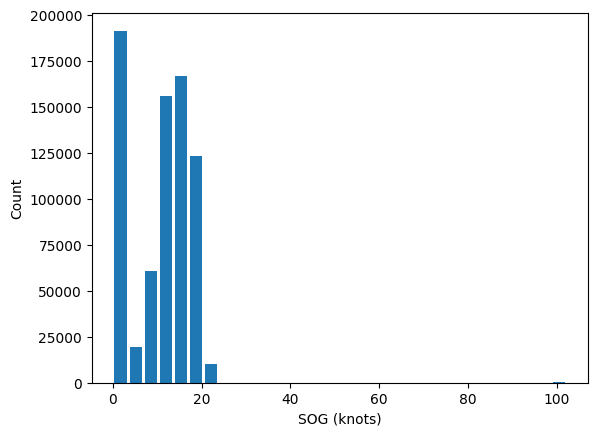

In [48]:
plt.hist(cargo_ais_meta_merged["speed_over_ground"], rwidth=0.8, bins=30)
plt.xlabel("SOG (knots)")
plt.ylabel("Count")
plt.show()

We also have lots of entries with SOG of 0, keep them as is for now and just remove  the upper 1% quantile outliers.

In [49]:

upper_q = 0.99

q_high = cargo_ais_meta_merged["speed_over_ground"].quantile(upper_q)

mask = cargo_ais_meta_merged["speed_over_ground"] <= q_high
cargo_ais_meta_merged = cargo_ais_meta_merged[mask]

In [50]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    721103.000000
mean         10.415315
std           6.766977
min           0.000000
25%           2.000000
50%          12.200000
75%          16.000000
max          20.799999
Name: speed_over_ground, dtype: float64

We now get way more realistic SOG values.

#### Coords

Longitude is expected to be [-180;180].

In [51]:
cargo_ais_meta_merged["longitude"].describe()

count    721103.000000
mean          2.563015
std          20.930832
min         -95.021350
25%          -3.042774
50%          -0.241065
75%           2.271056
max         123.744342
Name: longitude, dtype: float64

Latitude is expected to be [-90;90].

In [52]:
cargo_ais_meta_merged["latitude"].describe()

count    721103.000000
mean         30.283472
std          19.613719
min         -35.536462
25%          34.843640
50%          38.614312
75%          39.404062
max          60.196253
Name: latitude, dtype: float64

No impossible coords detected.

## Feature engineering

#### Calculate course deviation and include as feature<br>
Vessel can't deviate by more than 360 degrees total, so map to -180,180 degrees.

In [53]:
diff = cargo_ais_meta_merged["course_over_ground"] - cargo_ais_meta_merged["true_heading"]
cargo_ais_meta_merged["deg_off_course"] = ((diff + 180) % 360) - 180
cargo_ais_meta_merged["deg_off_course"].describe()

count    721103.000000
mean         -0.130321
std          52.360705
min        -180.000000
25%          -2.000000
50%           0.099998
75%           2.299988
max         179.900002
Name: deg_off_course, dtype: float64

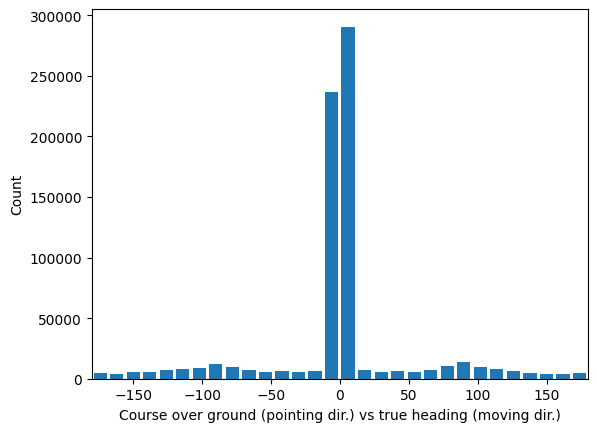

In [54]:
plt.hist(cargo_ais_meta_merged["deg_off_course"], rwidth=0.8, bins=30)
plt.xlim(-180, 180)
plt.xlabel("Course over ground (pointing dir.) vs true heading (moving dir.)")
plt.ylabel("Count")
plt.show()

### Include time-to-arrival (TTA) as feature (arrival time - timestamp)

In [55]:
cargo_ais_meta_merged["tta"] = cargo_ais_meta_merged["arrival_time"] - cargo_ais_meta_merged["pos_timestamp"]
cargo_ais_meta_merged["tta"].describe()

count                       721103
mean     4 days 06:29:03.466744763
std      6 days 04:34:37.973793910
min                0 days 00:02:00
25%                0 days 11:16:11
50%                1 days 15:25:10
75%                4 days 22:37:05
max        46 days 06:23:19.178000
Name: tta, dtype: object

In [56]:
cargo_ais_meta_merged["tta_hours"] = cargo_ais_meta_merged["tta"].dt.total_seconds() / 3600
cargo_ais_meta_merged["tta_hours"].describe().round(2)

count    721103.00
mean        102.48
std         148.58
min           0.03
25%          11.27
50%          39.42
75%         118.62
max        1110.39
Name: tta_hours, dtype: float64

### Include loading_pct as feauture (draught/max_draught)

In [57]:
cargo_ais_meta_merged["draught_max"].describe()

count    721103.000000
mean          7.390891
std           6.087395
min           0.000000
25%           0.000000
50%           8.800000
75%          13.000000
max          19.800000
Name: draught_max, dtype: float64

Since we can't divide by 0, make 0 NaN

In [58]:
import numpy as np
cargo_ais_meta_merged["draught_max"].replace(0, np.nan, inplace=True)

/tmp/ipykernel_34287/1570606653.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cargo_ais_meta_merged["draught_max"].replace(0, np.nan, inplace=True)


In [59]:
cargo_ais_meta_merged["draught_max"][22]

np.float64(nan)

In [60]:
cargo_ais_meta_merged["draught_max"].notna().sum()

np.int64(457729)

About 1/3 is missing draught_max
<br>1. Impute draught_max for missing vessels. Better if you don’t want to lose 1/3 of data:
<br>Group by vessel identity (e.g. mmsi or ship_type + commercial_size_class) and fill missing draught_max with a typical value in that group.​
<br>
<br>3. Use draught alone + “has_draught_max” flag. Tree models handle “sometimes NaN + binary flag” very well.
<br>If imputation feels too hacky, skip loading_pct for those rows and let the model know the metadata is missing:

In [61]:
cargo_ais_meta_merged["loading_pct"] = cargo_ais_meta_merged["draught"] / cargo_ais_meta_merged["draught_max"]
cargo_ais_meta_merged["loading_pct"].value_counts

<bound method IndexOpsMixin.value_counts of 3          0.915094
4          0.915094
5          0.915094
6          0.915094
22              NaN
             ...   
3311322    0.855172
3311323    0.855172
3311324    0.855172
3311325    0.855172
3311355    0.885135
Name: loading_pct, Length: 721103, dtype: float64>

### Drop immediately unnecessary columns

"capacity_liquid_oil", "capacity_liquid_gas" always 0, remove

In [62]:
cargo_ais_meta_merged["capacity_liquid_gas"].describe()

count    721103.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: capacity_liquid_gas, dtype: float64

In [63]:
cargo_ais_meta_merged["capacity_liquid_oil"].describe()

count    721103.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: capacity_liquid_oil, dtype: float64

In [64]:
unnecessary_lbls = ["capacity_liquid_gas", "capacity_liquid_oil", "arrival_country", "meta_source", "imo", "arrival_locode", "owner", "name", "manager", "builder", "destination", "class_society", "flag", "vid_prefix", "next_voyage_id", "prev_voyage_id", "departed_port_call_id", "arrived_port_call_id", "call_sign", "ref_point_a", "ref_point_b", "ref_point_c", "ref_point_d", "call_sign"]
features = cargo_ais_meta_merged.drop(columns=unnecessary_lbls)

In [65]:
features.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'ship_type',
       'position_device', 'eta', 'draught', 'meta_timestamp', 'build_year',
       'length', 'width', 'capacity_dwt', 'capacity_gt', 'capacity_teu',
       'capacity_passenger', 'commercial_size_class', 'vessel_type_details',
       'draught_max', 'draught_min', 'capacity_nt', 'month', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_latitude', 'arrival_longitude', 'duration',
       'arrival_date', 'in_bbox', 'deg_off_course', 'tta', 'tta_hours',
       'loading_pct'],
      dtype='object')

In [66]:
features["vessel_type_details"].unique()

array(['Bulk Carrier', 'Container Ship', 'Chemical Tanker',
       'Roll-on Roll-off', 'Pure Car Carrier', 'General Dry Cargo',
       'Tanker', 'LPG Carrier'], dtype=object)

add 1 size varaible and re-add loading_pct when missing rows have been fixed

In [67]:
feature_cols = ["deg_off_course", "voyage_status", "navigation_status", "position_accuracy", "longitude", "latitude", "raim", "rate_of_turn", "speed_over_ground", "position_device", "draught", "build_year", "month", "in_bbox", "length", "width", "capacity_nt", "capacity_dwt"]
features = cargo_ais_meta_merged[feature_cols]
features.shape

(721103, 18)

In [68]:
features["position_device"].unique()

array(['GPS', 'INTEGRATED_NAV_SYSTEM', 'COMBINED_GPS_GLONASS', 'GLONASS',
       'INTERNAL_GNSS', 'UNDEFINED', 'LORAN_C'], dtype=object)

In [69]:
features.columns

Index(['deg_off_course', 'voyage_status', 'navigation_status',
       'position_accuracy', 'longitude', 'latitude', 'raim', 'rate_of_turn',
       'speed_over_ground', 'position_device', 'draught', 'build_year',
       'month', 'in_bbox', 'length', 'width', 'capacity_nt', 'capacity_dwt'],
      dtype='object')

In [70]:
features.sample(10)

,deg_off_course,voyage_status,navigation_status,position_accuracy,longitude,latitude,raim,rate_of_turn,speed_over_ground,position_device,draught,build_year,month,in_bbox,length,width,capacity_nt,capacity_dwt
1019222,-69.200001,STOPPED,AT_ANCHOR,True,-0.280633,39.400885,False,0.0,0.400000,GPS,8.3,2001,2024-05,True,134.0,22.0,6006,11391
2521002,0.100006,UNDER_WAY,UNDER_WAY_USING_ENGINES,False,14.893707,-30.865337,False,0.0,17.200001,GPS,13.7,2013,2024-09,False,300.0,48.0,56260,110643
3055980,-153.000000,UNDER_WAY,UNDER_WAY_USING_ENGINES,False,-9.613333,43.948333,False,0.0,18.000000,GPS,10.0,2008,2024-12,False,260.0,32.0,24450,50727
3232382,3.100006,UNDER_WAY,UNDER_WAY_USING_ENGINES,True,-0.379167,50.475448,False,-5.0,16.500000,GPS,6.9,1998,2024-12,False,195.0,25.0,8790,14413
3236586,-128.000000,UNDER_WAY,UNDER_WAY_USING_ENGINES,False,89.161667,1.383333,False,0.0,16.000000,GPS,16.1,2021,2024-11,False,366.0,51.0,69253,155000
882936,-2.000000,UNDER_WAY,UNDER_WAY_USING_ENGINES,True,-0.270465,39.421027,False,1.0,9.900000,GPS,6.2,2011,2024-04,True,158.0,24.0,5339,14220
532847,-0.399994,UNDER_WAY,UNDER_WAY_USING_ENGINES,True,1.854660,39.451702,False,0.0,19.900000,GPS,6.0,2008,2024-03,False,199.0,26.0,11426,8500
2088530,6.100006,UNDER_WAY,UNDER_WAY_USING_ENGINES,True,-0.193455,39.413970,False,-720.0,3.900000,GPS,6.4,2011,2024-08,False,151.0,23.0,5400,12892
799560,1.000000,UNDER_WAY,UNDER_WAY_USING_ENGINES,False,-0.546460,37.536265,False,6.0,14.900000,GPS,8.2,2004,2024-04,False,208.0,30.0,12538,33829
1219826,-61.200000,STOPPED,AT_ANCHOR,False,-0.280222,39.394762,True,6.0,0.100000,GPS,5.6,2007,2024-05,True,129.0,21.0,3085,8146


ADD SIZE PROXY VAR - LEN, WIDTH, CAPACITY
MAX_DRAUGHT_PCT (MAX_LOADING_PCT?) VAR = draught/draught_max

### Heat map to display feature correlations

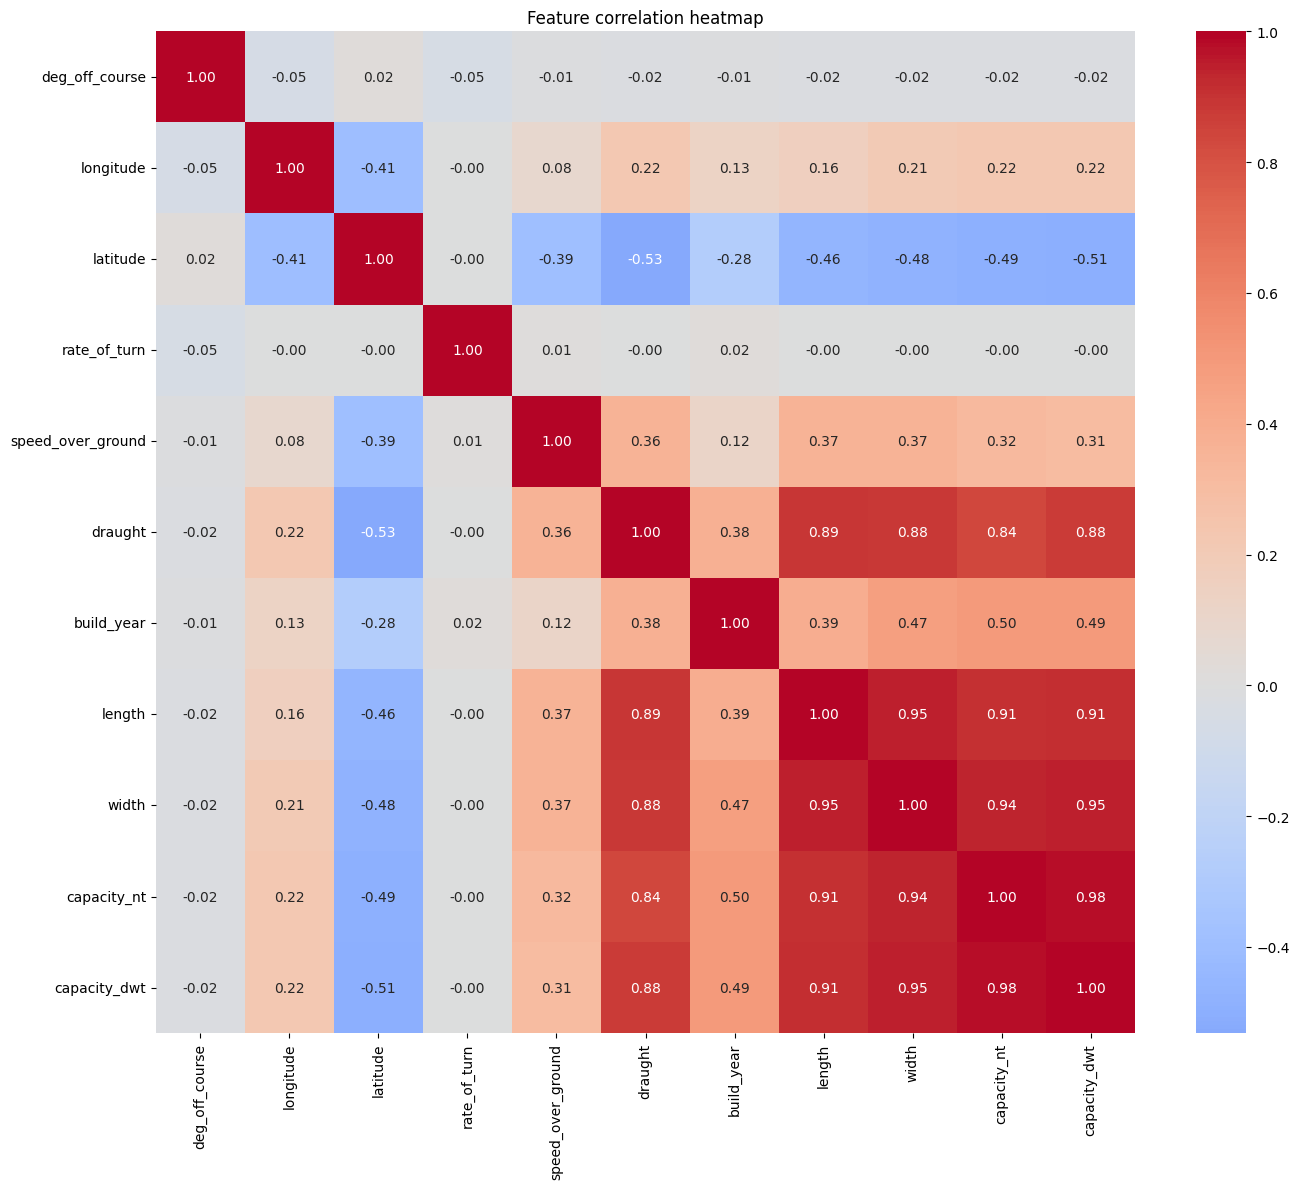

In [71]:
# seaborn correlation heatmap
import seaborn as sns

# 1) Select only numeric columns from your df (e.g. X_train)
num_df = features.select_dtypes(include=["number"])

# 2) Compute correlation matrix
corr = num_df.corr()

# 3) Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

We observe that draught, length, width, capacity_dwt, capacity_gw, capacity_teu, capacity_nt are all highly correlated.<br>
Perhaps we can combine these features into a singular feature.

## Model development

In [72]:
# Convert month to numeric FIRST
features['month'] = pd.to_datetime(features['month']).dt.month  # '2024-01' → 1

# Verify
print(features['month'].dtype, features['month'].unique())

int32 [ 1 12  2  3  4  5  6  7  8  9 10 11]


/tmp/ipykernel_34287/1008346622.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['month'] = pd.to_datetime(features['month']).dt.month  # '2024-01' → 1


In [73]:
df_model = cargo_ais_meta_merged.copy()

# 1) Clean label first
#df_model = df_model[~df_model["tta_hours"].isna()]

# 2) Sort by time
# df_model = df_model.sort_values("pos_timestamp") # if we sort now, meta data and feature data has diverged, so might not line up in the same time space

# 3) Build X, y
X = features
y = df_model["tta_hours"]

# 4) Time-based split
split_idx = int(len(df_model) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]


In [74]:
X_train.shape

(576882, 18)

In [75]:
X_train.head()

,deg_off_course,voyage_status,navigation_status,position_accuracy,longitude,latitude,raim,rate_of_turn,speed_over_ground,position_device,draught,build_year,month,in_bbox,length,width,capacity_nt,capacity_dwt
3,-4.100006,STOPPED,AT_ANCHOR,True,-0.257450,39.395163,False,0.0,0.0,GPS,9.7,2013,1,True,169.0,27.0,10500,28050
4,-47.100006,STOPPED,AT_ANCHOR,True,-0.257393,39.395095,False,0.0,0.0,GPS,9.7,2013,1,True,169.0,27.0,10500,28050
5,-1.699997,STOPPED,AT_ANCHOR,True,-0.257378,39.395087,False,0.0,0.1,GPS,9.7,2013,1,True,169.0,27.0,10500,28050
6,2.000000,STOPPED,AT_ANCHOR,True,-0.257395,39.395017,False,0.0,0.1,GPS,9.7,2013,1,True,169.0,27.0,10500,28050
22,3.799988,UNDER_WAY,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,False,720.0,11.2,GPS,9.7,1995,1,False,148.0,22.0,6784,18233


Learn the mean size of different commercial_size_class types to encode as numerical value (0-10 e.g.)
<br>one-hot encode navigation_status as ordinal value (no apparent ranking, just labels)

In [76]:
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()

In [77]:
cat_cols

['voyage_status',
 'navigation_status',
 'position_accuracy',
 'raim',
 'position_device',
 'in_bbox']

In [78]:
num_cols

['deg_off_course',
 'longitude',
 'latitude',
 'rate_of_turn',
 'speed_over_ground',
 'draught',
 'build_year',
 'month',
 'length',
 'width',
 'capacity_nt',
 'capacity_dwt']

### TRY XGBOOST (handles np.nan directly) so no need to impute
<br>Scale data?

In [82]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 576882 entries, 3 to 2722596
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   deg_off_course     576882 non-null  float64
 1   voyage_status      576882 non-null  object 
 2   navigation_status  576882 non-null  object 
 3   position_accuracy  576882 non-null  bool   
 4   longitude          576882 non-null  float64
 5   latitude           576882 non-null  float64
 6   raim               576882 non-null  bool   
 7   rate_of_turn       576882 non-null  float64
 8   speed_over_ground  576882 non-null  float64
 9   position_device    576882 non-null  object 
 10  draught            576882 non-null  float64
 11  build_year         576882 non-null  int64  
 12  month              576882 non-null  int32  
 13  in_bbox            576882 non-null  bool   
 14  length             576882 non-null  float64
 15  width              576882 non-null  float64
 16  capaci

In [86]:
X_train["position_device"].unique()

array(['GPS', 'INTEGRATED_NAV_SYSTEM', 'COMBINED_GPS_GLONASS', 'GLONASS',
       'INTERNAL_GNSS', 'UNDEFINED', 'LORAN_C'], dtype=object)

In [176]:
from xgboost import XGBRegressor

# convert object to categorical variable for xgboost
cat_cols = ["voyage_status", "navigation_status", "position_device"]

X_train = X_train.copy()  # Breaks slice reference
for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    
model_xgb = XGBRegressor(
    n_estimators=598,       # MORE trees
    max_depth=4,            # DEEPER trees  
    learning_rate=0.01,       # FASTER learning
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.01,          # LIGHT L1 (lat/lon still matter)
    reg_lambda=1,
    min_child_weight=5,      # Fight outliers
    tree_method='hist',
    enable_categorical=True,
    n_jobs=28,
    random_state=42,
    early_stopping_rounds=50 # Auto-stop
)

model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)


#model_xgb.fit(X_train, y_train)  # Raw df! No preprocess needed
print(f"Top features: \n{pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)}")


[0]	validation_0-rmse:163.08779
[100]	validation_0-rmse:98.58359
[200]	validation_0-rmse:83.73949
[300]	validation_0-rmse:80.52540
[400]	validation_0-rmse:79.60216
[500]	validation_0-rmse:79.05561
[597]	validation_0-rmse:78.92497
Top features: 
latitude             0.575714
longitude            0.251676
draught              0.026564
length               0.023055
speed_over_ground    0.022320
width                0.021956
navigation_status    0.014396
capacity_dwt         0.011020
build_year           0.009545
capacity_nt          0.008201
position_accuracy    0.006638
in_bbox              0.006466
month                0.006292
deg_off_course       0.006116
position_device      0.005496
voyage_status        0.004546
raim                 0.000000
rate_of_turn         0.000000
dtype: float32


In [114]:
cargo_ais_meta_merged["tta_hours"].max()

np.float64(1110.3886605555556)

In [102]:
ordinals = {
    'navigation_status': {
        'UNDER_WAY_USING_ENGINES': 0,      # cruising
        'UNDER_WAY_SAILING': 1,            # sailing  
        'AT_ANCHOR': 10,                   # stopped
        'MOORED': 10,                      # stopped
        'CONSTRAINED_BY_HER_DRAUGHT': 9,   # slow maneuvers
        'RESTRICTED_MANEUVERABILITY': 8,   # slow maneuvers
        'PUSHING_AHEAD_OR_TOWING_ALONGSIDE': 7  # slow/special
    },
    'position_accuracy': {0: 0, 1: 1},
    'raim': {False: 0, True: 1},
    'month': {i: i for i in range(1, 13)}
}

ordinal_cols = ['navigation_status', 'position_accuracy', 'raim', 'month']


In [103]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer([
    ("ordinals", OrdinalEncoder(categories=[list(ordinals[col].keys()) for col in ordinal_cols]), ordinal_cols),
    ("num", "passthrough", num_cols),
    # Scale?
])

In [180]:
model = Pipeline([
    ("preprocess", preprocess),           # splits num/cat correctly
    ("rf", RandomForestRegressor(n_estimators=200, max_depth=None, n_jobs=28))
])

In [181]:
model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinals', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Model evaluation

#### XGB

In [191]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Predictions on validation set
y_pred = model_xgb.predict(X_val)

# 2) Core regression metrics
mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)

print(f"MAE (hours):  {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")
print(f"R²:           {r2:.5f}")

# 3) Optional: quick sanity check of errors
errors = y_pred - y_val
print(errors.describe())

MAE (hours):  33.39
RMSE (hours): 78.92
R²:           0.76559
count    144221.000000
mean        -14.287462
std          77.621264
min        -745.475782
25%         -15.434750
50%           6.399104
75%          13.689241
max         176.737530
Name: tta_hours, dtype: float64


#### RF

In [182]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Predictions on validation set
y_pred = model.predict(X_val)

# 2) Core regression metrics
mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)

print(f"MAE (hours):  {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")
print(f"R²:           {r2:.5f}")

# 3) Optional: quick sanity check of errors
errors = y_pred - y_val
print(errors.describe())

MAE (hours):  34.70
RMSE (hours): 82.89
R²:           0.74146
count    144221.000000
mean        -16.486940
std          81.231413
min        -748.685799
25%         -18.962120
50%           0.460268
75%           9.765265
max         416.349762
Name: tta_hours, dtype: float64


In [192]:
pct_24hr = np.mean(np.abs(errors) < 24) * 100
print(f"Within 24hr: {pct_24hr:.1f}%")

Within 24hr: 70.2%


In [ ]:
import joblib
joblib.dump(model_xgb, "xgb_0.joblib")

In [ ]:
import joblib
model = joblib.load("model1.joblib")